## Polynomial Regression from scratch

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
class PolynomialRegression:
    def __init__(self, p, learning_rate, epochs):
        self.p = p
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.w = None
        self.b = None
    
    def transform_features(self, X):
        X = (X-self.mean)/self.std
        X = np.asarray(X)
        X_transformed = np.zeros((X.shape[0],self.p))
        for i in range(1,self.p+1):
            X_transformed[:,i-1] = X[:,0]**i
           
        return X_transformed
            
    def predict(self,X):
        X_transformed = self.transform_features(X)
        return X_transformed @ self.w + self.b
    
    
    def fit(self, X, y):
        self.mean = X.mean()
        self.std = X.std()
        
        X = np.asarray(X)
        y = np.asarray(y).ravel()
        n_samples, n_features = X.shape
        self.w = np.zeros(self.p)
        self.b = 0
        
        for i in range(self.epochs):
            # step - 1: predict for given X
            X_transformed = self.transform_features(X)
            y_pred = X_transformed @ self.w + self.b
            
             # step - 2: gradients w.r.t w,b
            dw = - (1/n_samples)*(X_transformed.T @ (y - y_pred))
            db = - (1/n_samples)*(np.sum(y-y_pred))
            
            # step - 3: update w,b using gradients
            self.w -= self.learning_rate*dw
            self.b -= self.learning_rate*db
            
            # step - 4: calculate the mse for analysing the perfomance
            mse = (1/2)*np.mean((y-y_pred)**2)
            
            if (i%10)==0:
                print(f"MSE for {i}th iteration: {mse}")
            
        
        

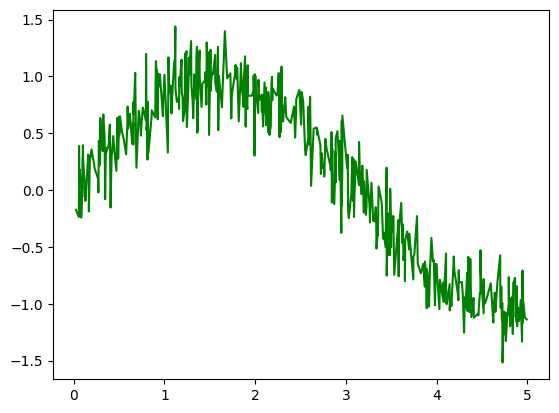

In [89]:
np.random.seed(0)
X_poly = np.sort(5 * np.random.rand(500, 1), axis=0)
Y_poly = np.sin(X_poly).ravel() + np.random.normal(0, 0.2, X_poly.shape[0])
plt.plot(X_poly,Y_poly,color='g' )

MSE for 0th iteration: 0.2812241886081018
MSE for 10th iteration: 0.13260737324277544
MSE for 20th iteration: 0.11150926763736768
MSE for 30th iteration: 0.09540175356804695
MSE for 40th iteration: 0.08266449454835473
MSE for 50th iteration: 0.07249300071365762
MSE for 60th iteration: 0.06429192295915401
MSE for 70th iteration: 0.057617072999102174
MSE for 80th iteration: 0.05213515652192424
MSE for 90th iteration: 0.04759449455808746
MSE for 100th iteration: 0.04380368871452794
MSE for 110th iteration: 0.04061604732304158
MSE for 120th iteration: 0.0379181934019835
MSE for 130th iteration: 0.0356217111175611
MSE for 140th iteration: 0.03365700255645926
MSE for 150th iteration: 0.03196875457770778
MSE for 160th iteration: 0.030512580451595165
MSE for 170th iteration: 0.029252520370449807
MSE for 180th iteration: 0.028159171345472758


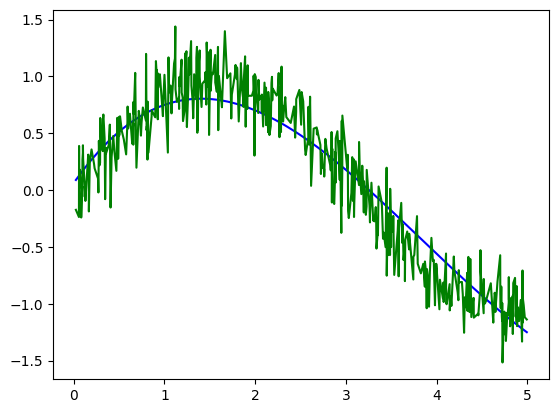

In [92]:
poly_reg = PolynomialRegression(p=3, learning_rate=0.05, epochs = 190)
poly_reg.fit(X_poly, Y_poly)
Y_pred_poly = poly_reg.predict(X_poly)
plt.plot(X_poly, Y_pred_poly, color='b')
plt.plot(X_poly,Y_poly,color='g' )
plt.show()